In [ ]:
!pip install --upgrade keras

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 31.4 MB/s eta 0:00:00
  Attempting uninstall: keras
    Found existing installation: keras 3.10.0
    Uninstalling keras-3.10.0:
      Successfully uninstalled keras-3.10.0


In [ ]:
import keras

In [ ]:
hidden_dim = 512
batch_size = 64

In [ ]:
import tensorflow as tf

cross_entropy = tf.keras.losses.BinaryCrossentropy()

In [ ]:
import tensorflow as tf
# tf.config.run_functions_eagerly(True)

class Generator(keras.Model):
    def __init__(self):
        super().__init__()
        # Decoder:
        self.dense = keras.layers.Dense(12*12*hidden_dim, use_bias=False)
        self.bn_dense = keras.layers.BatchNormalization()
        self.leaky_relu1 = keras.layers.LeakyReLU(0.2)

        self.reshape = keras.layers.Reshape(target_shape=(12, 12, hidden_dim))

        self.upsamp1 = keras.layers.UpSampling2D(size=(2, 2))
        self.conv1 = keras.layers.Conv2D(64, 3, padding="same", use_bias=False)
        self.bn1 = keras.layers.BatchNormalization()
        self.leaky_relu2 = keras.layers.LeakyReLU(0.2)

        self.upsamp2 = keras.layers.UpSampling2D(size=(2, 2))
        self.conv2 = keras.layers.Conv2D(128, 5, padding="same", use_bias=False)
        self.bn2 = keras.layers.BatchNormalization()
        self.leaky_relu3 = keras.layers.LeakyReLU(0.2)

        self.upsamp3 = keras.layers.UpSampling2D(size=(2, 2))
        self.conv3 = keras.layers.Conv2D(128, 5, padding="same", use_bias=False)
        self.bn3 = keras.layers.BatchNormalization()
        self.leaky_relu4 = keras.layers.LeakyReLU(0.2)

        self.conv4 = keras.layers.Conv2D(3, 3, padding="same", activation="tanh")

    def call(self, inputs, training=False):
        # Decoder:
        x = self.dense(inputs)
        x = self.bn_dense(x, training=training)
        x = self.leaky_relu1(x)

        x = self.reshape(x)

        x = self.upsamp1(x)
        x = self.conv1(x)
        x = self.bn1(x, training=training)
        x = self.leaky_relu2(x)

        x = self.upsamp2(x)
        x = self.conv2(x)
        x = self.bn2(x, training=training)
        x = self.leaky_relu3(x)

        x = self.upsamp3(x)
        x = self.conv3(x)
        x = self.bn3(x, training=training)
        x = self.leaky_relu4(x)

        x = self.conv4(x)
        return x

class Discriminator(keras.Model):
    def __init__(self):
        # Discriminator:
        super().__init__()
        self.conv1 = keras.layers.Conv2D(64, 3, padding="same")
        self.leaky_relu1 = keras.layers.LeakyReLU(0.2)
        self.dropout1 = keras.layers.Dropout(0.3)
        self.maxpool1 = keras.layers.MaxPool2D(pool_size=(2, 2), strides=(2, 2), padding="same")

        self.conv2 = keras.layers.Conv2D(128, 5, padding="same")
        self.leaky_relu2 = keras.layers.LeakyReLU(0.2)
        self.dropout2 = keras.layers.Dropout(0.3)
        self.maxpool2 = keras.layers.MaxPool2D(pool_size=(2, 2), strides=(2, 2), padding="same")

        self.conv3 = keras.layers.Conv2D(128, 5, padding="same")
        self.leaky_relu3 = keras.layers.LeakyReLU(0.2)
        self.dropout3 = keras.layers.Dropout(0.3)
        self.maxpool3 = keras.layers.MaxPool2D(pool_size=(2, 2), strides=(2, 2), padding="same")
        self.flatten = keras.layers.Flatten()

        self.dense1 = keras.layers.Dense(64, activation="relu")
        self.dense2 = keras.layers.Dense(1, activation="sigmoid")

    def call(self, inputs, training=False):
        # Discriminator:
        x = self.conv1(inputs)
        x = self.leaky_relu1(x)
        x = self.dropout1(x, training=training)
        x = self.maxpool1(x)

        x = self.conv2(x)
        x = self.leaky_relu2(x)
        x = self.dropout2(x, training=training)
        x = self.maxpool2(x)

        x = self.conv3(x)
        x = self.leaky_relu3(x)
        x = self.dropout3(x, training=training)
        x = self.maxpool3(x)
        x = self.flatten(x)

        x = self.dense1(x)
        x = self.dense2(x)
        return x

class GAN_Model(keras.Model):
    def __init__(self):
        super().__init__()
        self.generator = Generator()
        self.discriminator = Discriminator()

    def build(self, input_shape):
        super().build(input_shape)
        # Это нестабильные параметры - высока вероятность градиентного взрыва (РАСКОМИТИТЬ ПРИ ДООБУЧЕНИИ!!!)
        self.d_optimizer = tf.keras.optimizers.Adam(0.00065, beta_1=0.5)
        self.g_optimizer = tf.keras.optimizers.Adam(0.0002, beta_1=0.5)

    def call(self, inputs, training=False):
        print(batch_size)
        print(hidden_dim)
        # noise = tf.random.normal(shape=(batch_size, hidden_dim))
        noise = inputs
        generated_images = self.generator(noise)

        return generated_images

    def train_step(self, data):
        img, _ = data

        # Discriminator:
        with tf.GradientTape() as tape:
            noise = tf.random.normal(shape=(batch_size, hidden_dim))

            generated_images = self.generator(noise)

            real_predictions = self.discriminator(img)
            fake_predictions = self.discriminator(generated_images)

            real_loss = cross_entropy(tf.ones_like(real_predictions), real_predictions)
            fake_loss = cross_entropy(tf.zeros_like(fake_predictions), fake_predictions)

            loss_dis = real_loss + fake_loss

        gradients = tape.gradient(loss_dis, self.discriminator.trainable_variables)
        self.d_optimizer.apply_gradients(zip(gradients, self.discriminator.trainable_variables))

        # Generator:
        with tf.GradientTape() as tape:
            noise = tf.random.normal(shape=(batch_size, hidden_dim))

            generated_images = self.generator(noise)

            fake_predictions = self.discriminator(generated_images)

            loss_gen = cross_entropy(tf.ones_like(fake_predictions), fake_predictions)

        gradients = tape.gradient(loss_gen, self.generator.trainable_variables)
        self.g_optimizer.apply_gradients(zip(gradients, self.generator.trainable_variables))

        return {"loss_gen": loss_gen, "loss_dis": loss_dis}

In [ ]:
model = GAN_Model()
model(tf.random.normal(shape=(1, hidden_dim)))
model.summary()
generator = model.generator
generator(tf.random.normal(shape=(1, hidden_dim)))
generator.summary()
discriminator = model.discriminator
discriminator(tf.random.uniform((1, 96, 96, 3)))
discriminator.summary()

64
512


Model: "gan__model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ generator (Generator)           │ ?                      │    38,957,699 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ discriminator (Discriminator)   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 38,957,699 (148.61 MB)

 Trainable params: 38,809,603 (148.05 MB)

...

Model: "discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (1, 96, 96, 64)        │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (1, 48, 48, 128)       │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (1, 24, 24, 128)       │       409,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_6 (LeakyReLU)       │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (1, 18432)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (1, 64)                │     1,179,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (1, 1)                 │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,796,225 (6.85 MB)

 Trainable params: 1,796,225 (6.85 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
def show_images(images, titles=None, cols=5):
    n = len(images)
    rows = (n + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(cols*3, rows*3))

    axes = axes.flatten() if hasattr(axes, 'flatten') else [axes]

    for i, img in enumerate(images):
        axes[i].imshow(img)
        axes[i].axis('off')

        if titles and i < len(titles):
            axes[i].set_title(titles[i])
        else:
            axes[i].set_title(f'{i+1}')

    for i in range(n, len(axes)):
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

In [ ]:
model.load_weights("best_gan_weights.h5")
# model.load_weights("horror_gan_weights_v2_1.h5")
# model.load_weights("horror_gan_weights_v2_2.h5")

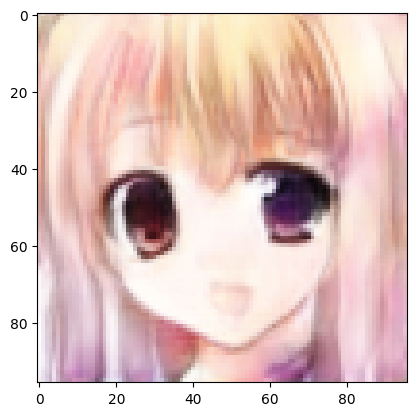

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import random
import os

seed = 45

tf.random.set_seed(seed)
np.random.seed(seed)
random.seed(seed)

noise = tf.random.normal(shape=(1, hidden_dim))

generation = (model.generator(noise, training=False) + 1) / 2.0

plt.imshow(generation[0])

In [ ]:
import shutil

if os.path.exists("results"):
  shutil.rmtree("results")

os.makedirs("results", exist_ok=True)

# seed = 58

# tf.random.set_seed(seed)
# np.random.seed(seed)
# random.seed(seed)

noise = tf.random.normal(shape=(1, hidden_dim))

generated_images = []

for i in range(10):
  generated_image = model.generator(noise, training=False)
  gen_img = (generated_image[0] + 1) / 2.0
  generated_images.append(gen_img)
  print(noise[0][0])
  noise = noise * 0.65

for i, gen_img in enumerate(generated_images):
  path = os.path.join("results/", f"gen_img_{i}.png")
  plt.imsave(path, gen_img.numpy())

tf.Tensor(0.44079486, shape=(), dtype=float32)
tf.Tensor(0.28651664, shape=(), dtype=float32)
tf.Tensor(0.1862358, shape=(), dtype=float32)
tf.Tensor(0.12105326, shape=(), dtype=float32)
tf.Tensor(0.07868462, shape=(), dtype=float32)
tf.Tensor(0.051145002, shape=(), dtype=float32)
tf.Tensor(0.03324425, shape=(), dtype=float32)
tf.Tensor(0.02160876, shape=(), dtype=float32)
tf.Tensor(0.014045694, shape=(), dtype=float32)
tf.Tensor(0.0091297, shape=(), dtype=float32)


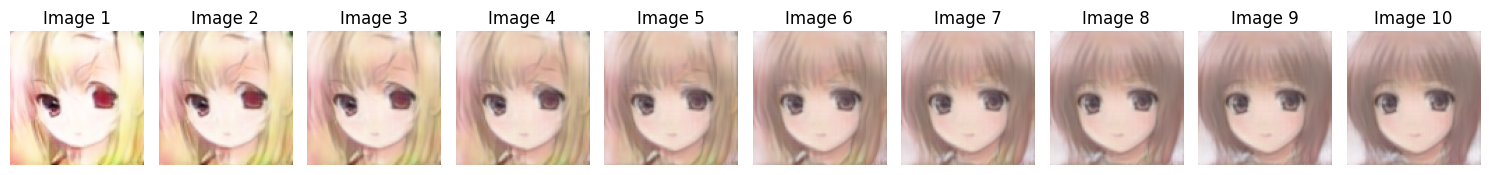

In [ ]:
fig, axes = plt.subplots(1, len(generated_images), figsize=(15, 5))

for i, gen_img in enumerate(generated_images):
    axes[i].imshow(gen_img)
    axes[i].axis('off')
    axes[i].set_title(f'Image {i+1}')

plt.tight_layout()
plt.show()

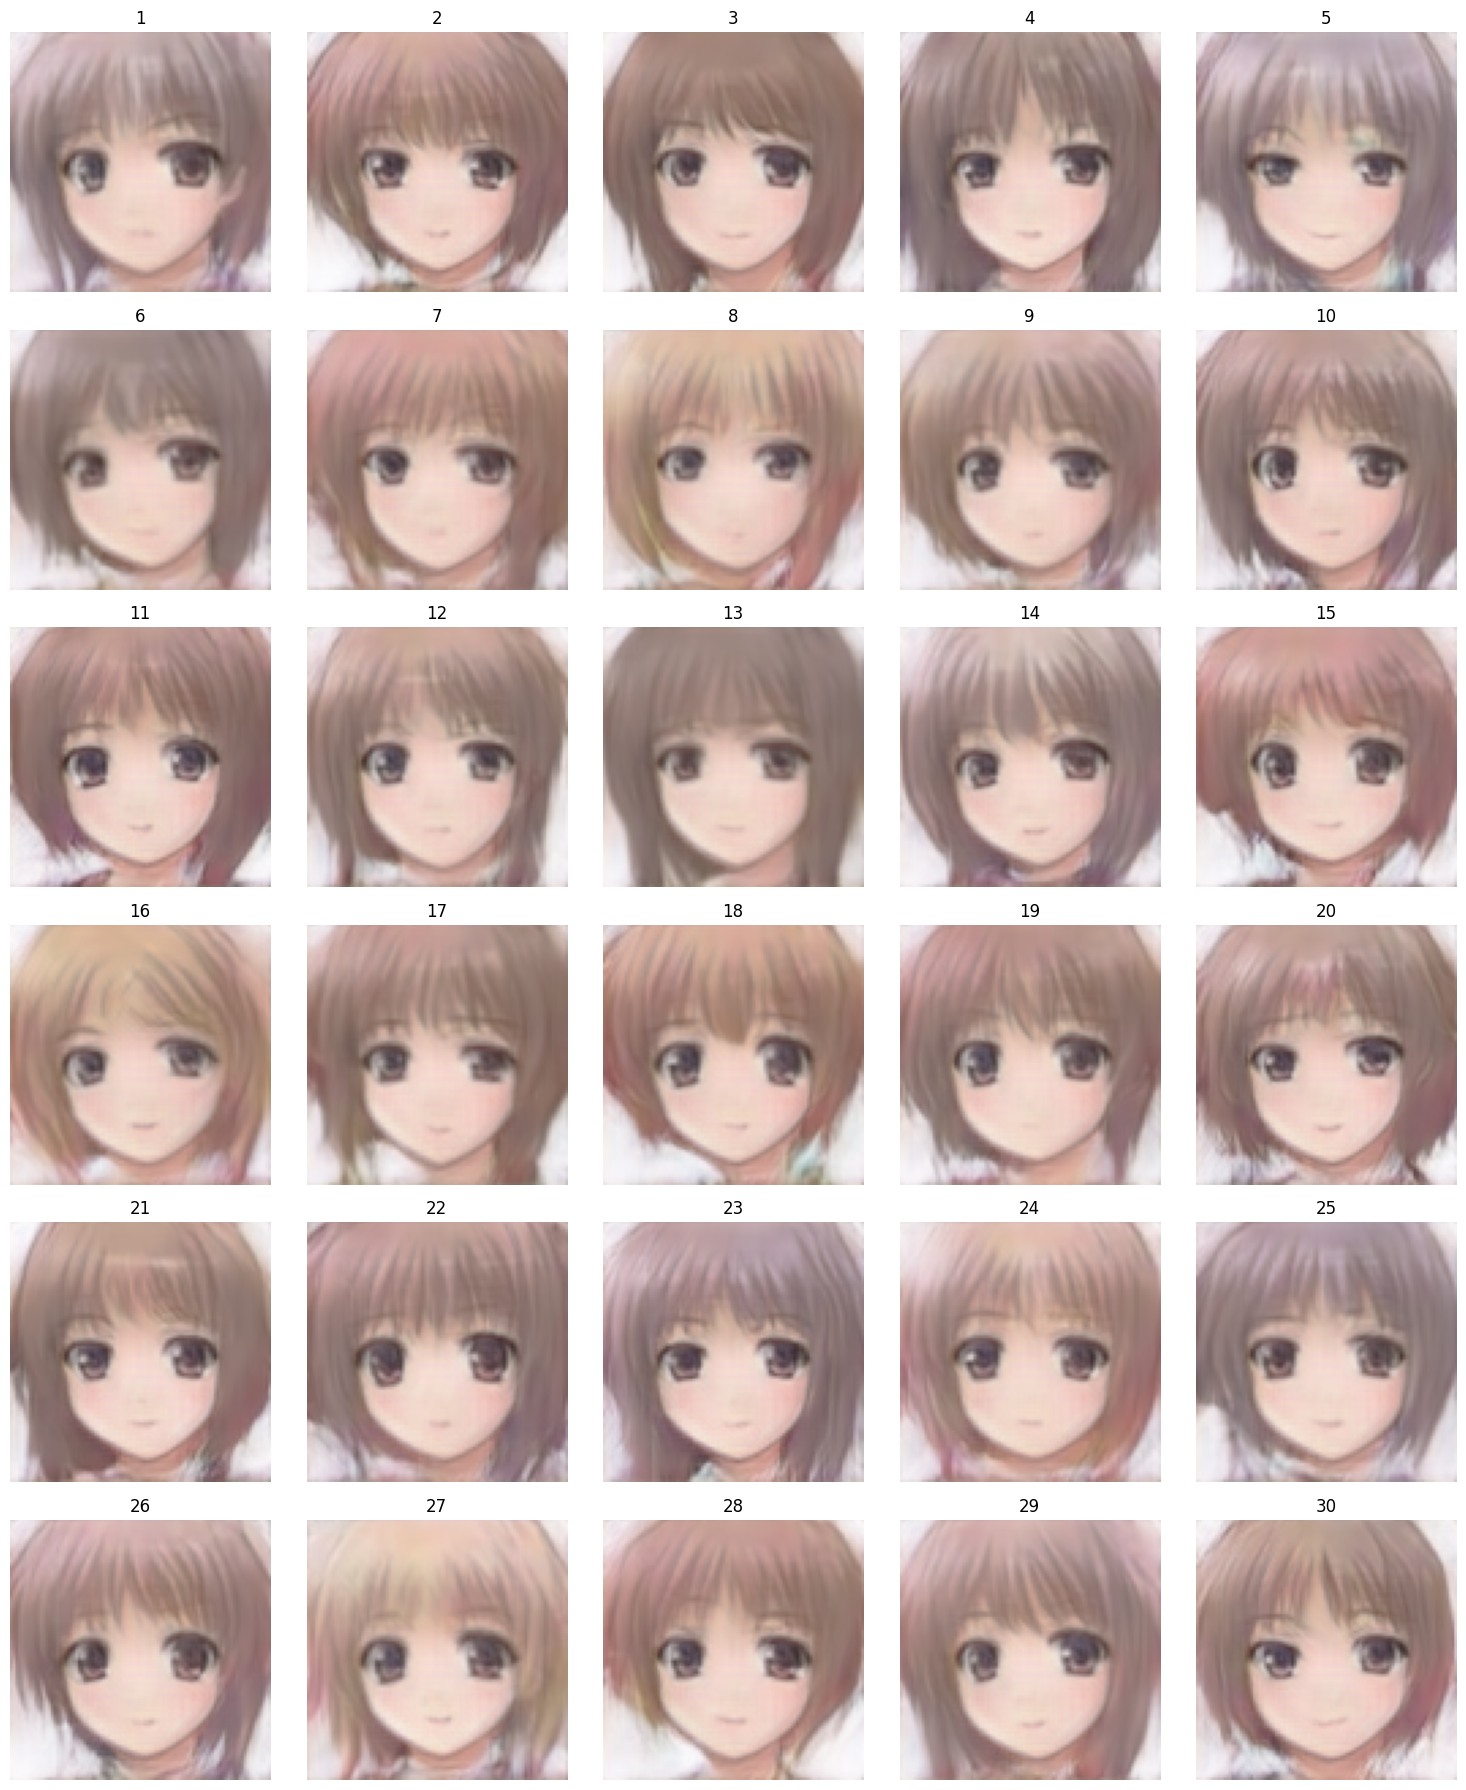

In [ ]:
# Из эксперемента выше была найдена область в латентном пространстве, которая позволяет генерировать
# вполне понятные и красивые картинки. Девушка на 10 картинке сверху - это идеальная модель, которую
# смогла выработать нейронная сеть. По ней вближайшей окрестности можно строить похожие на неё, но всё же
# разные картинки:
if os.path.exists("perfect_imgs"):
  shutil.rmtree("perfect_imgs")

os.makedirs("perfect_imgs", exist_ok=True)

def generate_perfect_imgs(num_girls=10):
    perfect_imgs = []

    for i in range(num_girls):
        # Используем найденный "sweet spot"
        base_mult = 0.65**5 # 0.17850625

        # Генерируем несколько вариаций для каждого множителя
        for j in range(3):
            noise = tf.random.normal(shape=(1, hidden_dim)) * base_mult
            noise += tf.random.normal(shape=(1, hidden_dim)) * 0.03  # вариация

            generated_image = model.generator(noise, training=False)
            perfect_imgs.append((generated_image[0] + 1) / 2.0)

    return perfect_imgs

perfect_imgs = generate_perfect_imgs(10)

for i, gen_img in enumerate(perfect_imgs):
  path = os.path.join("perfect_imgs/", f"gen_img_{i}.png")
  plt.imsave(path, gen_img.numpy())

show_images(perfect_imgs)

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os
import shutil
from PIL import Image

# Создаем папку для результатов
if os.path.exists("results"):
    shutil.rmtree("results")
os.makedirs("results", exist_ok=True)

noise1 = tf.random.normal(shape=(1, hidden_dim)) * 0.65**4.5 + tf.random.normal(shape=(1, hidden_dim)) * 0.03
noise2 = tf.random.normal(shape=(1, hidden_dim)) * 0.65**4.5 + tf.random.normal(shape=(1, hidden_dim)) * 0.03
generated_images = []

iterations = 45
img_num = 1

for k in range(55):
  for i in range(iterations):
    generated_image = model.generator(noise1, training=False)
    gen_img = (generated_image[0] + 1) / 2.0
    generated_images.append(gen_img)

    # Сохраняем каждый кадр как отдельное изображение
    plt.figure(figsize=(8, 8))
    plt.imshow(gen_img.numpy())
    plt.axis('off')
    plt.title(f'Frame {img_num}', fontsize=16)
    plt.tight_layout()
    plt.savefig(f"results/frame_{img_num:03d}.png", bbox_inches='tight', pad_inches=0, dpi=80)
    plt.close()

    img_num += 1

    # Движение в скрытом пространстве
    alpha = i / iterations
    noise1 = (1 - alpha) * noise1 + alpha * noise2

    if noise1[0][0] / noise2[0][0] > 0.9:
        noise2 = tf.random.normal(shape=(1, hidden_dim)) * 0.65**4.5
        break

    print(f"Сгенерирован кадр {img_num}")

frames = []
for i in range(1, img_num):
    frame = Image.open(f"results/frame_{i:03d}.png")
    frames.append(frame)

frames[0].save(
    "generation_animation.gif",
    format='GIF',
    append_images=frames[1:],
    save_all=True,
    duration=48,  # продолжительность каждого кадра в миллисекундах
    loop=0,       # бесконечный цикл
    optimize=True
)

Сгенерирован кадр 4
Сгенерирован кадр 5
Сгенерирован кадр 6
Сгенерирован кадр 7
Сгенерирован кадр 8
Сгенерирован кадр 9
Сгенерирован кадр 10
Сгенерирован кадр 11
Сгенерирован кадр 12
Сгенерирован кадр 13
Сгенерирован кадр 14
Сгенерирован кадр 15
Сгенерирован кадр 16
Сгенерирован кадр 17
Сгенерирован кадр 18
Сгенерирован кадр 19
Сгенерирован кадр 21
Сгенерирован кадр 22
Сгенерирован кадр 23
Сгенерирован кадр 24
Сгенерирован кадр 25
Сгенерирован кадр 26
Сгенерирован кадр 27
Сгенерирован кадр 28
Сгенерирован кадр 29
Сгенерирован кадр 30
Сгенерирован кадр 31
Сгенерирован кадр 32
Сгенерирован кадр 33
Сгенерирован кадр 34
Сгенерирован кадр 35
Сгенерирован кадр 36
Сгенерирован кадр 38
Сгенерирован кадр 39
Сгенерирован кадр 40
Сгенерирован кадр 41
Сгенерирован кадр 42
Сгенерирован кадр 43
Сгенерирован кадр 44
Сгенерирован кадр 45
Сгенерирован кадр 46
Сгенерирован кадр 47
Сгенерирован кадр 48
Сгенерирован кадр 49
Сгенерирован кадр 50
Сгенерирован кадр 51
Сгенерирован кадр 52
Сгенерирован кадр 5

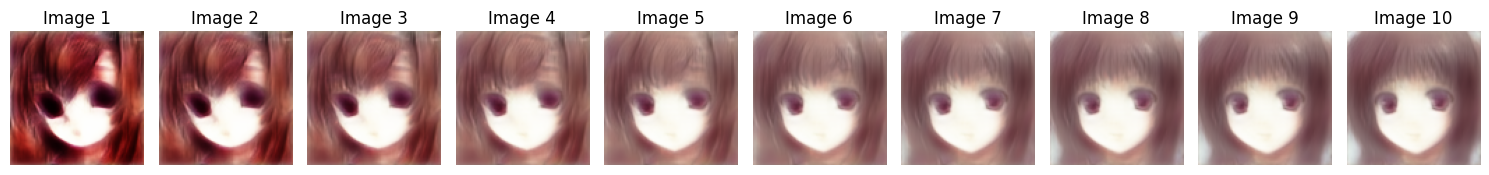

In [ ]:
# fig, axes = plt.subplots(1, len(generated_images), figsize=(15, 5))

# for i, gen_img in enumerate(generated_images):
#     axes[i].imshow(gen_img)
#     axes[i].axis('off')
#     axes[i].set_title(f'Image {i+1}')

# plt.tight_layout()
# plt.show()